# Project Idea:
Building an CNN model that can analyze an image of a plant leaf and determine whether it is healthy or infected with a specific disease.

Class	Description:

healthy	The leaf is healthy

multiple_diseases	The leaf has multiple diseases

rust	The leaf is affected by rust disease

scab	The leaf is affected by scab disease



# `01` Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import random

----------------------------

# `02` Load and explore  Data
[Dataset Link](https://www.kaggle.com/competitions/plant-pathology-2020-fgvc7)

In [321]:
df=pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Plant-Disease-CNn\plant-pathology-2020-fgvc7\train.csv")
df.head()

 

,image_id,healthy,multiple_diseases,rust,scab
0,Train_0,0,0,0,1
1,Train_1,0,1,0,0
2,Train_2,1,0,0,0
3,Train_3,0,0,1,0
4,Train_4,1,0,0,0


In [322]:
df.shape

(1821, 5)

In [323]:
df.iloc[:,1:].sum()

healthy              516
multiple_diseases     91
rust                 622
scab                 592
dtype: int64

 healthy: Very

Multiple diseases: Few

This is called Imbalanced Dataset.

In [324]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1821 entries, 0 to 1820
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   image_id           1821 non-null   object
 1   healthy            1821 non-null   int64 
 2   multiple_diseases  1821 non-null   int64 
 3   rust               1821 non-null   int64 
 4   scab               1821 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 71.3+ KB


# EDA 

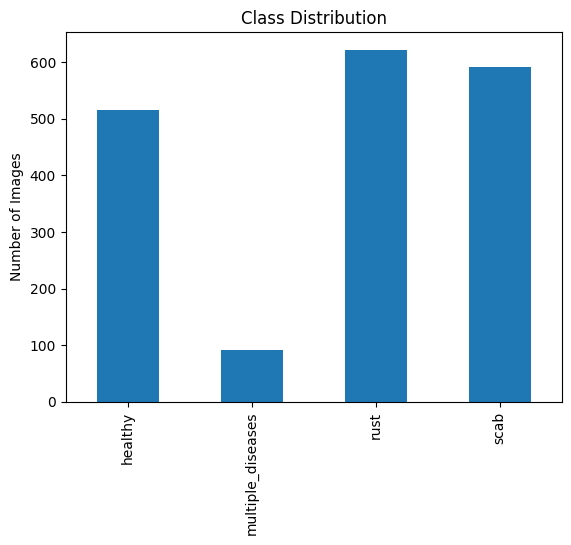

In [325]:
import matplotlib.pyplot as plt

df.iloc[:,1:].sum().plot(kind='bar')
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()


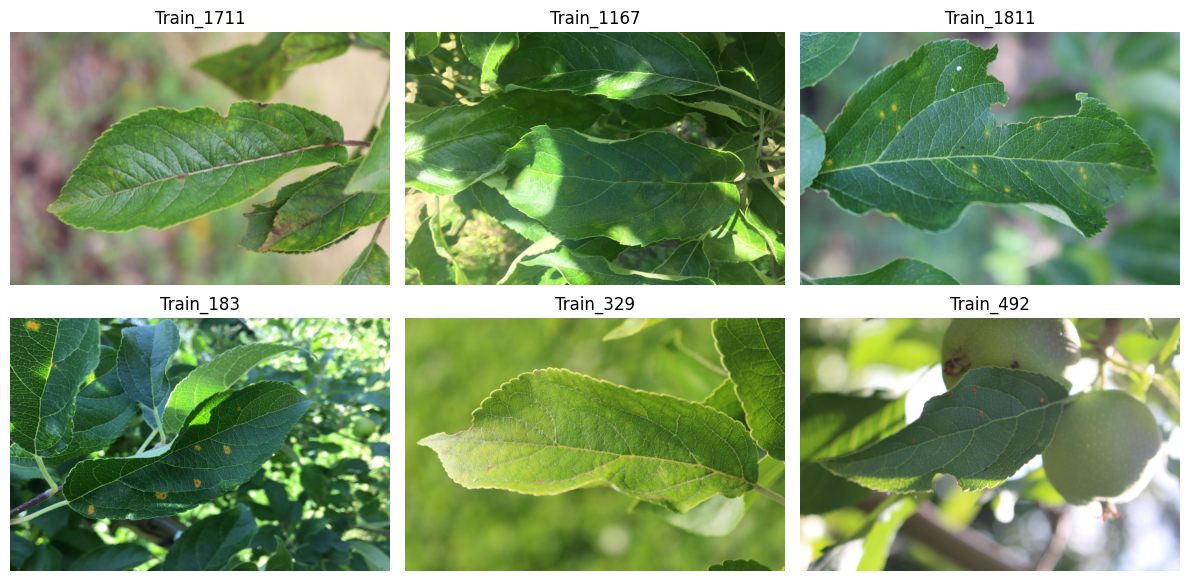

In [326]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image_path = r'C:\Users\DELL\OneDrive\Desktop\Plant-Disease-CNn\plant-pathology-2020-fgvc7\images'


df['filename'] = df['image_id'] + '.jpg'

 
sample_df = df.sample(6)

plt.figure(figsize=(12,6))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img_path = os.path.join(image_path, row['filename'])
    img = mpimg.imread(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(row['image_id'])  

plt.tight_layout()
plt.show()

I visualized random samples directly from the training dataframe to ensure I was inspecting only labeled training data.

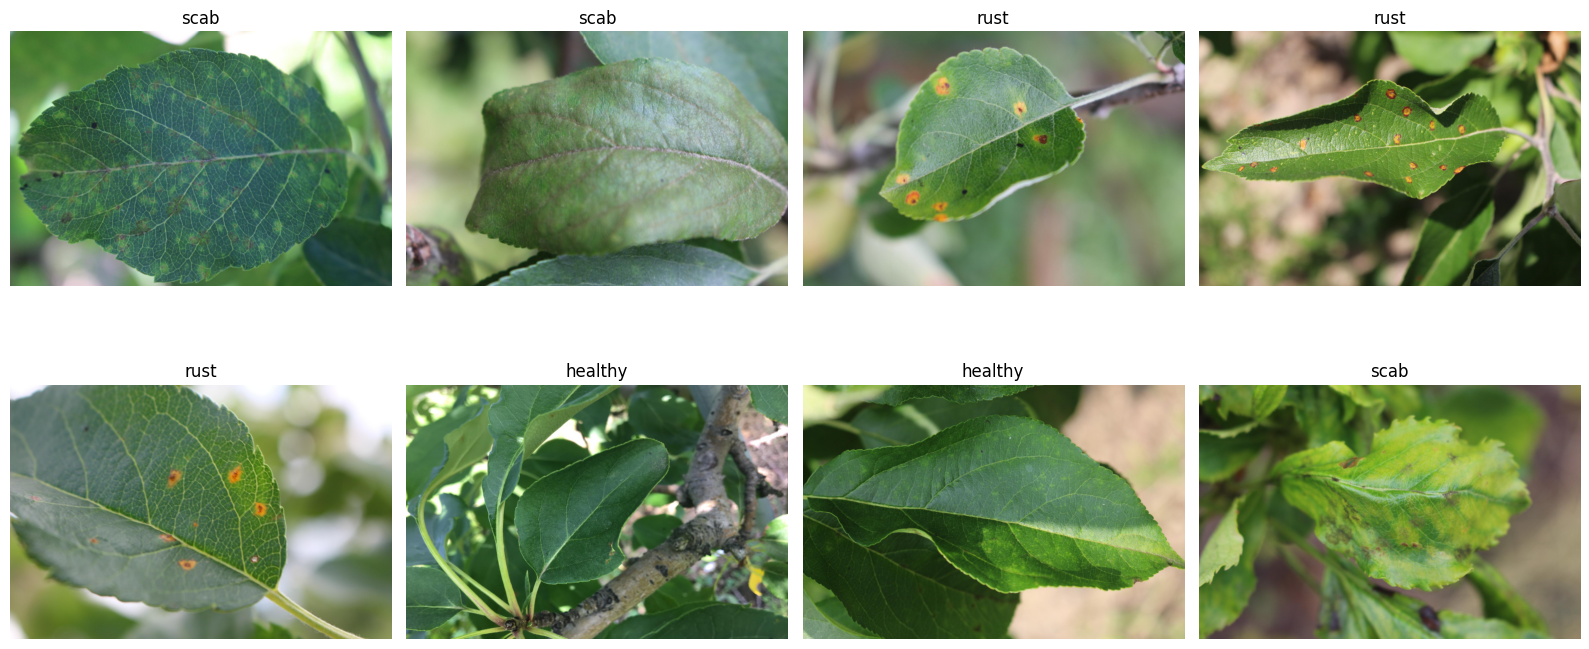

In [327]:


df['label'] = df[['healthy', 'scab', 'rust', 'multiple_diseases']].idxmax(axis=1)
 
sample_df = df.sample(8)

plt.figure(figsize=(16, 8))

for i, row in enumerate(sample_df.itertuples()):
    img_path = os.path.join(image_path, row.filename)
    
    img = mpimg.imread(img_path)
    
    plt.subplot(2, 4, i+1)   
    plt.imshow(img)
    plt.title(row.label)
    plt.axis('off')

plt.tight_layout()
plt.show()


# `03`Data Augmentation

In [328]:
datagen = ImageDataGenerator(
    rescale=1./255,

    # 🔥 Enhanced Augmentation لتقليل overfitting
    rotation_range=40,
    zoom_range=0.3,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,  # إضافة vertical flip
    brightness_range=[0.7,1.3],  # توسيع range
    channel_shift_range=0.1,  # إضافة channel shift

    # تقسيم البيانات
    validation_split=0.2
)

In [329]:
df['label'] = df[['healthy','multiple_diseases','rust','scab']].idxmax(axis=1)

# Generators

In [330]:
train_generator = datagen.flow_from_dataframe(
        dataframe=df,
        directory=image_path,
        x_col='filename',
        y_col='label',
        target_size=(224, 224),
        class_mode='categorical',
        subset='training',
        batch_size=32,
        shuffle=True
)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)




val_generator = val_datagen.flow_from_dataframe(
    dataframe=df,
    directory=image_path,
    x_col='filename',
    y_col='label',
    
    target_size=(224,224),
    batch_size=32,
    
    class_mode='categorical',
    subset='validation',
    
    shuffle=False
)

Found 1457 validated image filenames belonging to 4 classes.
Found 364 validated image filenames belonging to 4 classes.


#class weight 

 to solve Imbalanced Dataset.

In [331]:
 

# نحول labels لأرقام
labels = df['label'].values

# نحولها لأرقام (encoding)
classes = np.unique(labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=labels
)

# نحولها dict
class_weights = dict(zip(classes, class_weights))

print(class_weights)

{'healthy': np.float64(0.8822674418604651), 'multiple_diseases': np.float64(5.002747252747253), 'rust': np.float64(0.7319131832797428), 'scab': np.float64(0.7690033783783784)}


In [332]:
class_indices = train_generator.class_indices
print(class_indices)

{'healthy': 0, 'multiple_diseases': 1, 'rust': 2, 'scab': 3}


In [333]:
class_weights_corrected = {
    class_indices[k]: v for k, v in class_weights.items()
}

# `04` Model Building

In [334]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

## Fine-Tuning - unfreeze more layers
for layer in base_model.layers[:-80]:  # زيادة عدد الlayers المجمدة
    layer.trainable = False

for layer in base_model.layers[-80:]:
    layer.trainable = True


x = base_model.output
x = GlobalAveragePooling2D()(x)

# إضافة Batch Normalization و L2 regularization
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)  # زيادة dropout

x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)  # زيادة dropout

output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile

In [ ]:
loss = CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=Adam(learning_rate=1e-4),  # استخدام fixed learning rate
    loss=loss,
    metrics=['accuracy']
)

# Callbacks

In [336]:
from tensorflow.keras.callbacks import ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,  # زيادة patience
        restore_best_weights=True,
        min_delta=0.001  # minimum change to qualify as improvement
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,  # أكثر تدريجية
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    # إضافة Model Checkpoint
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

## `05` Training

In [337]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=60,  # زيادة عدد epochs
    class_weight=class_weights_corrected,
    callbacks=callbacks  # إضافة callbacks
)

Epoch 1/60
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3223 - loss: 2.6690
Epoch 1: val_accuracy improved from None to 0.39560, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.3528 - loss: 2.5380 - val_accuracy: 0.3956 - val_loss: 1.8723 - learning_rate: 1.0000e-04
Epoch 2/60
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4807 - loss: 2.1599
Epoch 2: val_accuracy improved from 0.39560 to 0.51099, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.5065 - loss: 2.1628 - val_accuracy: 0.5110 - val_loss: 1.7614 - learning_rate: 1.0000e-04
Epoch 3/60
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5688 - loss: 1.9496
Epoch 3: val_accuracy improved from 0.51099 to 0.57143, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accu

TypeError: This optimizer was created with a `LearningRateSchedule` object as its `learning_rate` constructor argument, hence its learning rate is not settable. If you need the learning rate to be settable, you should instantiate the optimizer with a float `learning_rate` argument.

## `06` Evaluate the Model

## Load Best Model & Evaluate

In [ ]:
# Load the best model
best_model = tf.keras.models.load_model('best_model.keras')

# Evaluate on validation data
val_loss, val_accuracy = best_model.evaluate(val_generator)

print(f"Best Model - Validation Accuracy: {val_accuracy:.4f}")
print(f"Best Model - Validation Loss: {val_loss:.4f}")

# predict probabilities with best model
y_pred_probs = best_model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
# Evaluate on validation data
val_loss, val_accuracy = model.evaluate(val_generator)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 599ms/step - accuracy: 0.8214 - loss: 0.6596
Validation Accuracy: 0.8214
Validation Loss: 0.6596


In [ ]:
 
 

# predict probabilities
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# true labels
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 618ms/step
Classification Report:

                   precision    recall  f1-score   support

          healthy       0.75      0.98      0.85        88
multiple_diseases       0.24      0.40      0.30        20
             rust       0.92      0.84      0.88       116
             scab       0.97      0.77      0.86       140

         accuracy                           0.82       364
        macro avg       0.72      0.75      0.72       364
     weighted avg       0.86      0.82      0.83       364


Confusion Matrix:
 [[ 86   0   1   1]
 [  3   8   7   2]
 [ 10   9  97   0]
 [ 15  17   0 108]]


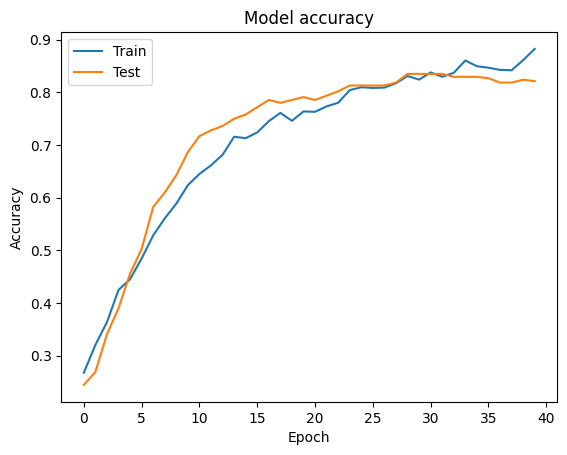

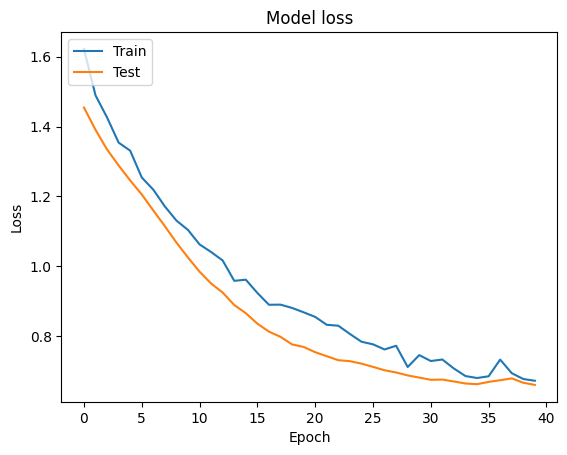

In [ ]:
 
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

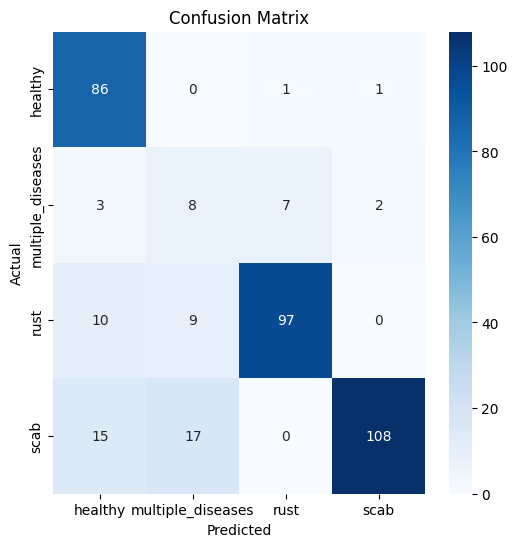

In [ ]:
 
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
 

def predict_image(img_path, model):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    pred_class = np.argmax(pred)

    class_names = ['healthy','multiple_diseases','rust','scab']

    return class_names[pred_class], pred[0]

In [ ]:
 
random_image = random.choice(os.listdir(image_path))
img_path = os.path.join(image_path, random_image)

label, probs = predict_image(img_path, model)

print("Image:", random_image)
print("Prediction:", label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 790ms/step
Image: Test_1183.jpg
Prediction: multiple_diseases


In [ ]:
model.save("plant_model_final.h5")

In [ ]:
# Save best model in H5 format for Streamlit app
best_model.save("plant_model_final.h5")
print("Best model saved as plant_model_final.h5")